In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

In [2]:
housing = fetch_california_housing()
Data = pd.DataFrame(housing.data, columns=housing.feature_names)

In [ ]:
# Data.info()
print(Data.head)
# print(Data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB
<bound method NDFrame.head of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.846

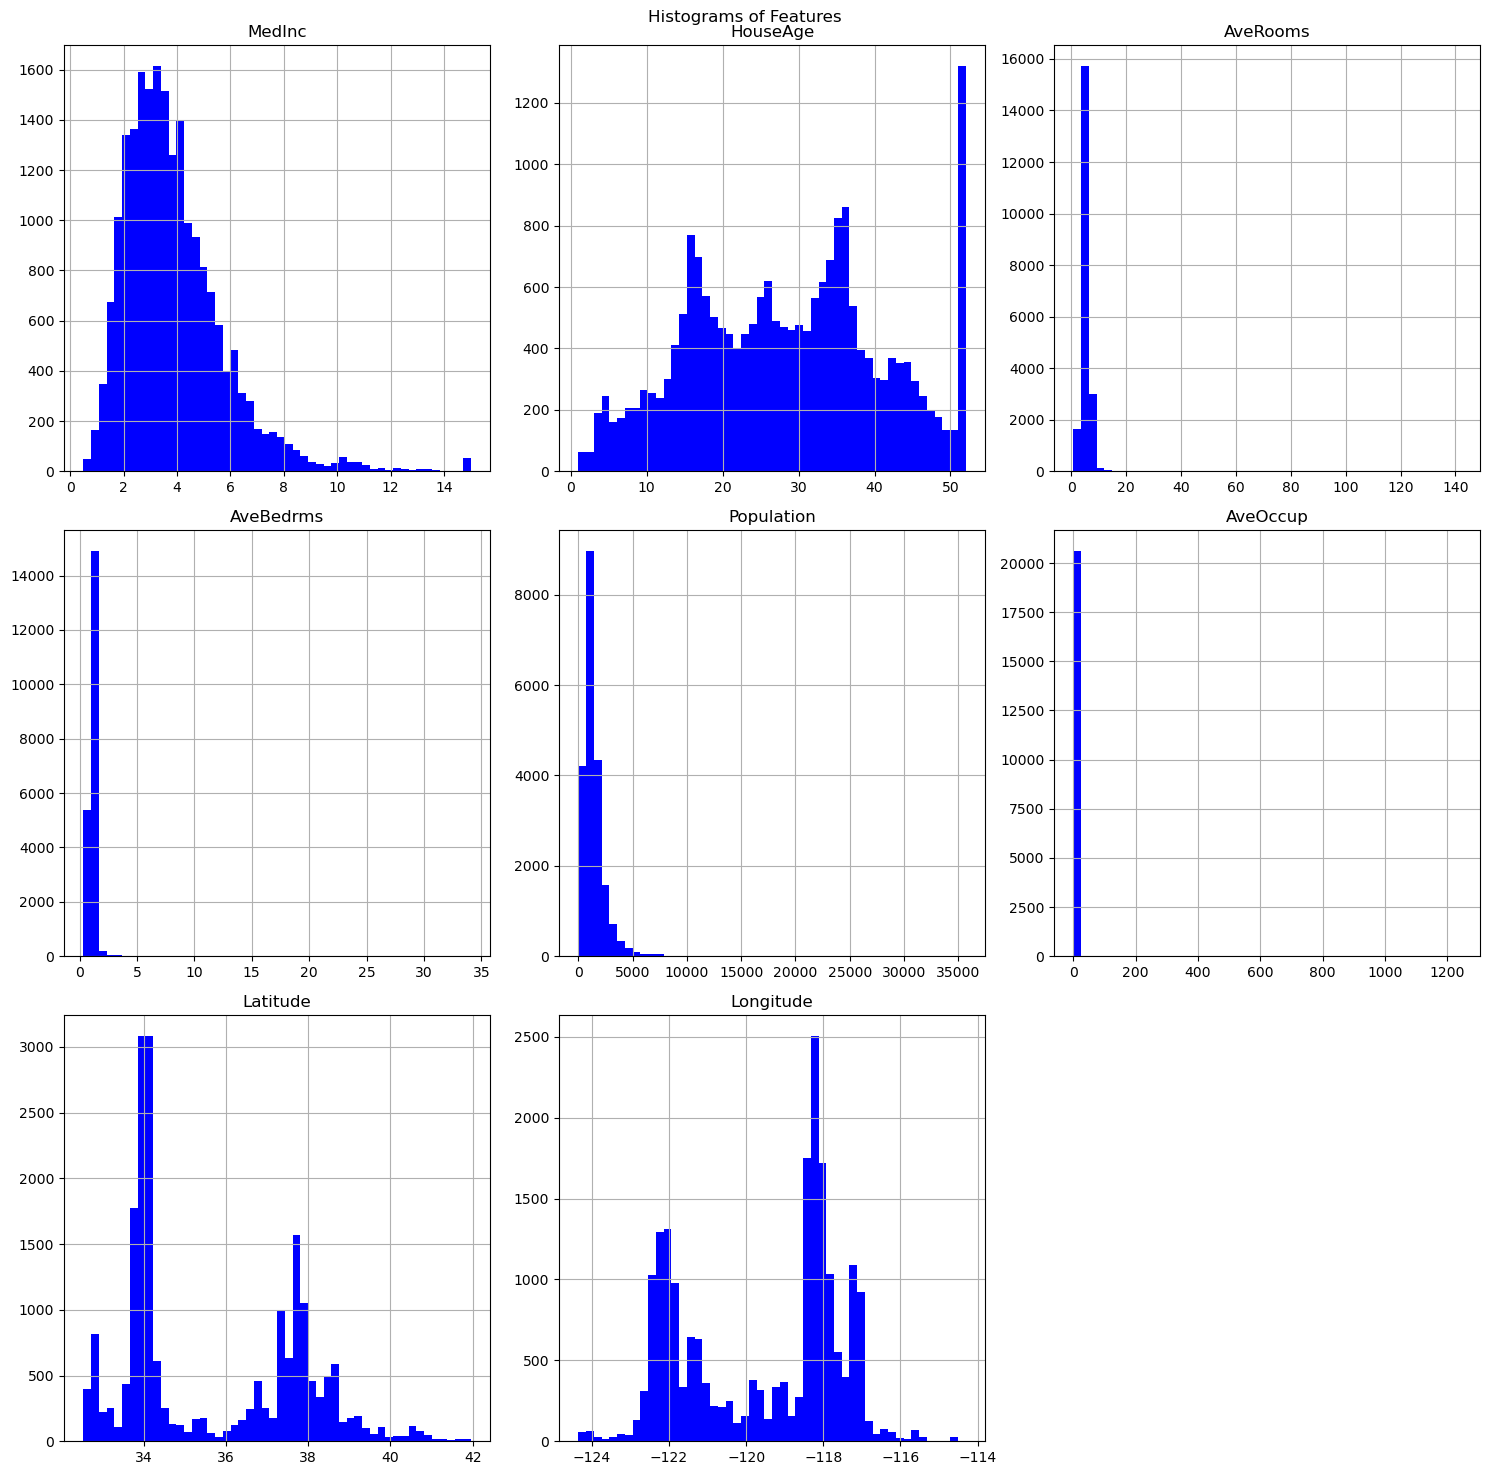

In [4]:
Data.hist(bins=50, figsize=(15, 15), color='blue')
plt.suptitle("Histograms of Features")
plt.tight_layout()
plt.show()

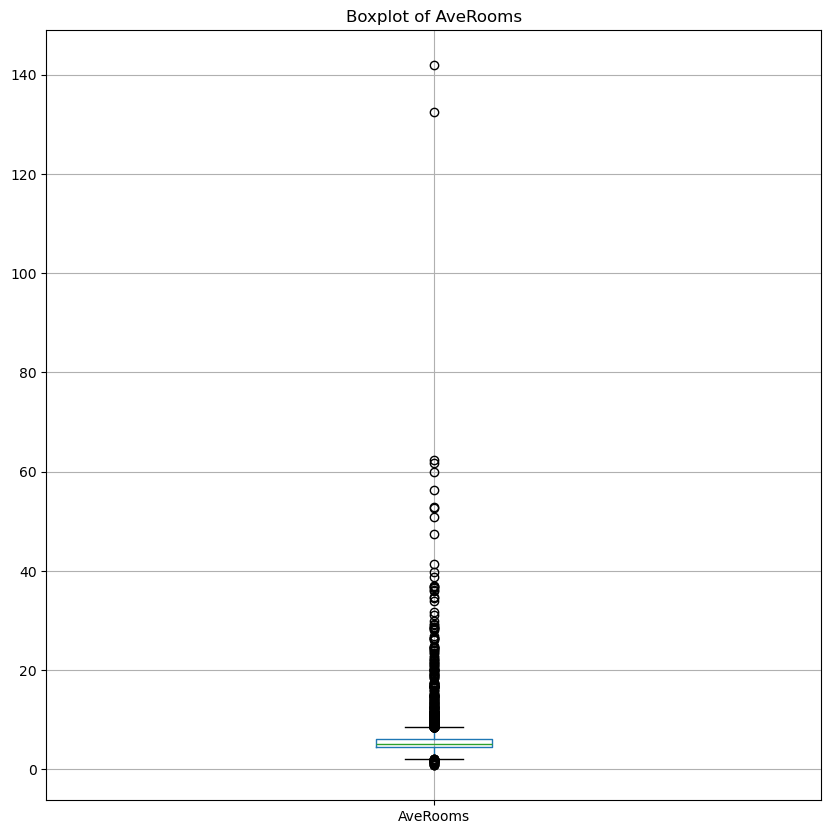

In [5]:
Data.boxplot(column='AveRooms', figsize=(10, 10))
plt.title("Boxplot of AveRooms")
plt.show()

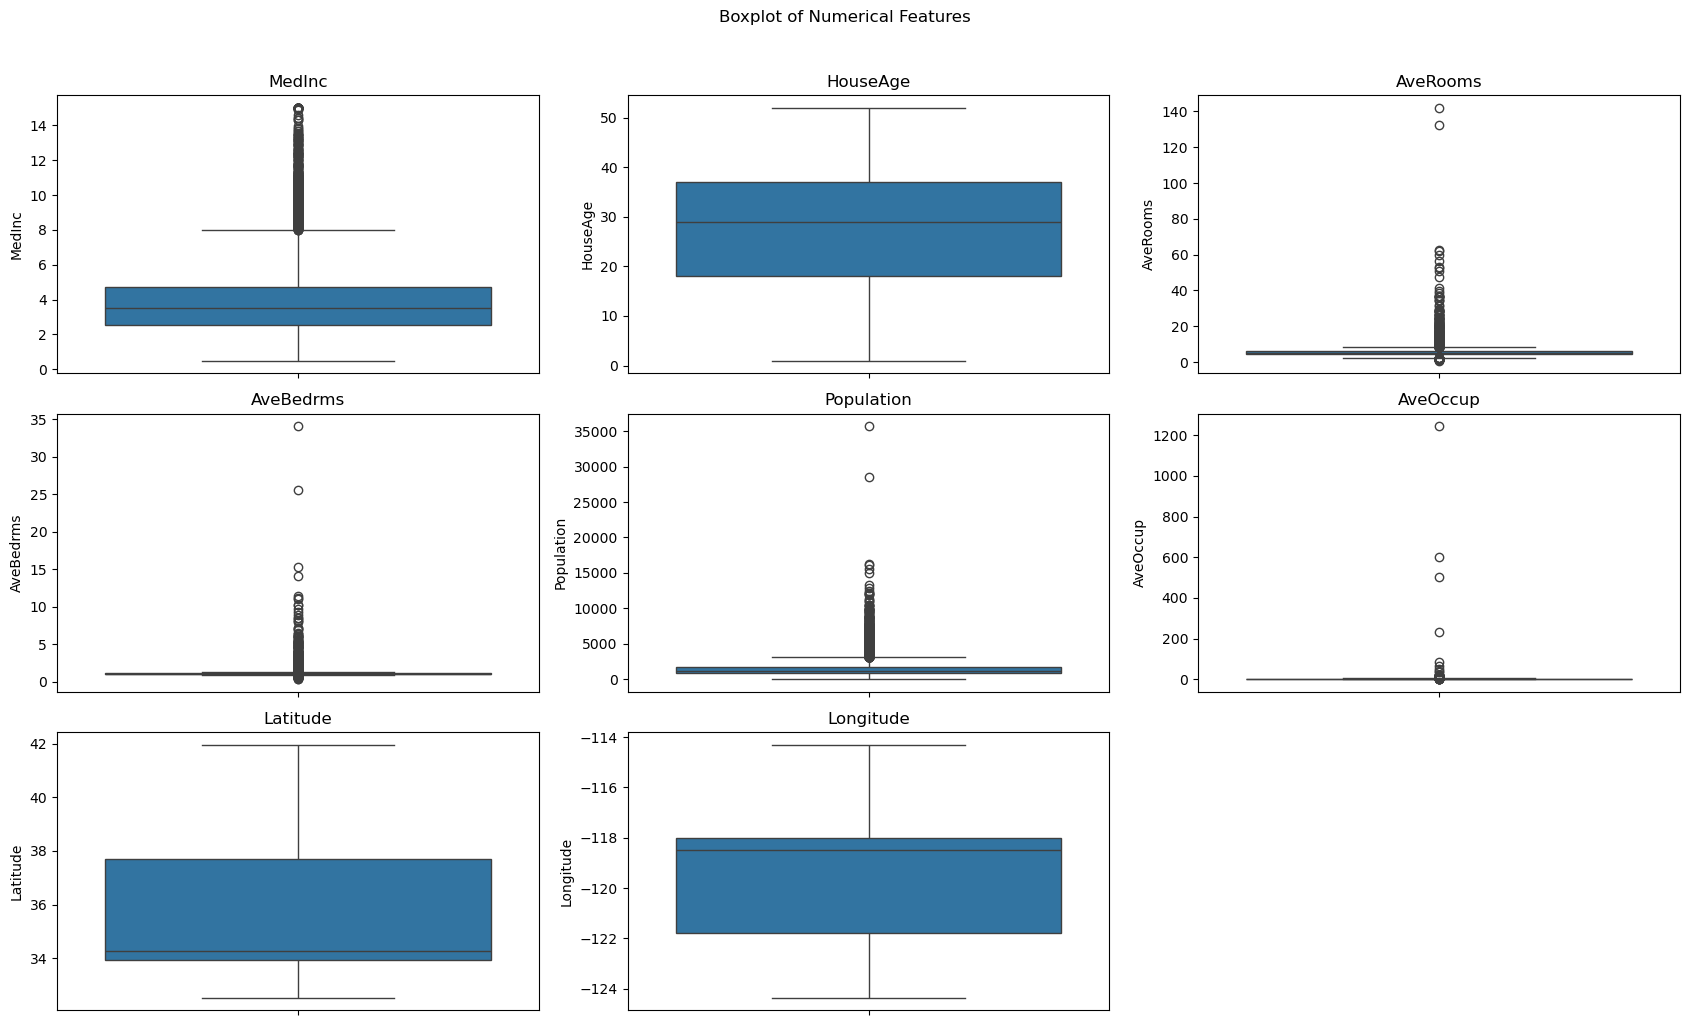

In [6]:
plt.figure(figsize=(17, 10))
for i, column in enumerate(Data.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=Data[column])
    plt.title(column)
plt.suptitle("Boxplot of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()

In [7]:
def detect_outliers_iqr(data):
    outliers = {}
    for column in data.columns:
        Q1 = np.percentile(data[column], 25)
        Q3 = np.percentile(data[column], 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_values = data[(data[column] < lower_bound) | (data[column] > upper_bound)][column]
        outliers[column] = outlier_values.tolist()
    return outliers

In [8]:
outliers_dict = detect_outliers_iqr(Data)
for feature, outliers in outliers_dict.items():
    print(f"{feature}: {len(outliers)} outliers found")

MedInc: 681 outliers found
HouseAge: 0 outliers found
AveRooms: 511 outliers found
AveBedrms: 1424 outliers found
Population: 1196 outliers found
AveOccup: 711 outliers found
Latitude: 0 outliers found
Longitude: 0 outliers found
